# NORMALISASI MIN-MAX #

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ==============================================================================
# DATA
# ==============================================================================
df_minmax = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_minmax[kolom_string] = df_minmax[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_minmax.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_minmax

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [2]:
# ==============================================================================
# STANDARDISASI MIN-MAX
# ==============================================================================
scaler = MinMaxScaler()

df_minmax[kolom_numerik] = scaler.fit_transform(df_minmax[kolom_numerik])

print("========== HASIL STANDARDISASI MIN-MAX ==========")
df_minmax

========== HASIL STANDARDISASI MIN-MAX ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000


* AGGLOMERATIVE HIERARCHICAL CLUSTERING


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

In [4]:
#===============================================================================
# DATA
#===============================================================================

df_minmax_ahc = df_minmax.copy()
df_minmax_ahc

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000


In [5]:
#===============================================================================
# 1. HITUNG MATRIKS JARAK/LINKAGE
#===============================================================================

linkage_matrix = linkage(
    df_minmax_ahc[kolom_numerik],
    method="ward",
    metric="euclidean"
)

print("========== HASIL LINKAGE MATRIX ==========")
linkage_matrix

========== HASIL LINKAGE MATRIX ==========


array([[7.50000000e+01, 1.13000000e+02, 1.37548263e-02, 2.00000000e+00],
       [2.40000000e+01, 6.20000000e+01, 1.46820155e-02, 2.00000000e+00],
       [2.70000000e+01, 6.50000000e+01, 1.54882620e-02, 2.00000000e+00],
       ...,
       [5.26000000e+02, 5.27000000e+02, 4.18455923e+00, 2.10000000e+02],
       [5.24000000e+02, 5.28000000e+02, 5.11031566e+00, 2.17000000e+02],
       [4.98000000e+02, 5.29000000e+02, 5.79274117e+00, 2.66000000e+02]])

In [6]:
#===============================================================================
# 2. PASANGAN CLUSTER TERDEKAT
#===============================================================================

linkage_df = pd.DataFrame(
    linkage_matrix,
    columns=[
        "Cluster 1",
        "Cluster 2",
        "Jarak",
        "Jumlah Anggota"
    ]
)

print("========== PASANGAN CLUSTER TERDEKAT ==========")
linkage_df

========== PASANGAN CLUSTER TERDEKAT ==========


,Cluster 1,Cluster 2,Jarak,Jumlah Anggota
0,75.0,113.0,0.013755,2.0
1,24.0,62.0,0.014682,2.0
2,27.0,65.0,0.015488,2.0
3,56.0,94.0,0.016013,2.0
4,32.0,70.0,0.016248,2.0
...,...,...,...,...
260,519.0,523.0,2.411495,87.0
261,518.0,525.0,3.471304,123.0
262,526.0,527.0,4.184559,210.0
263,524.0,528.0,5.110316,217.0


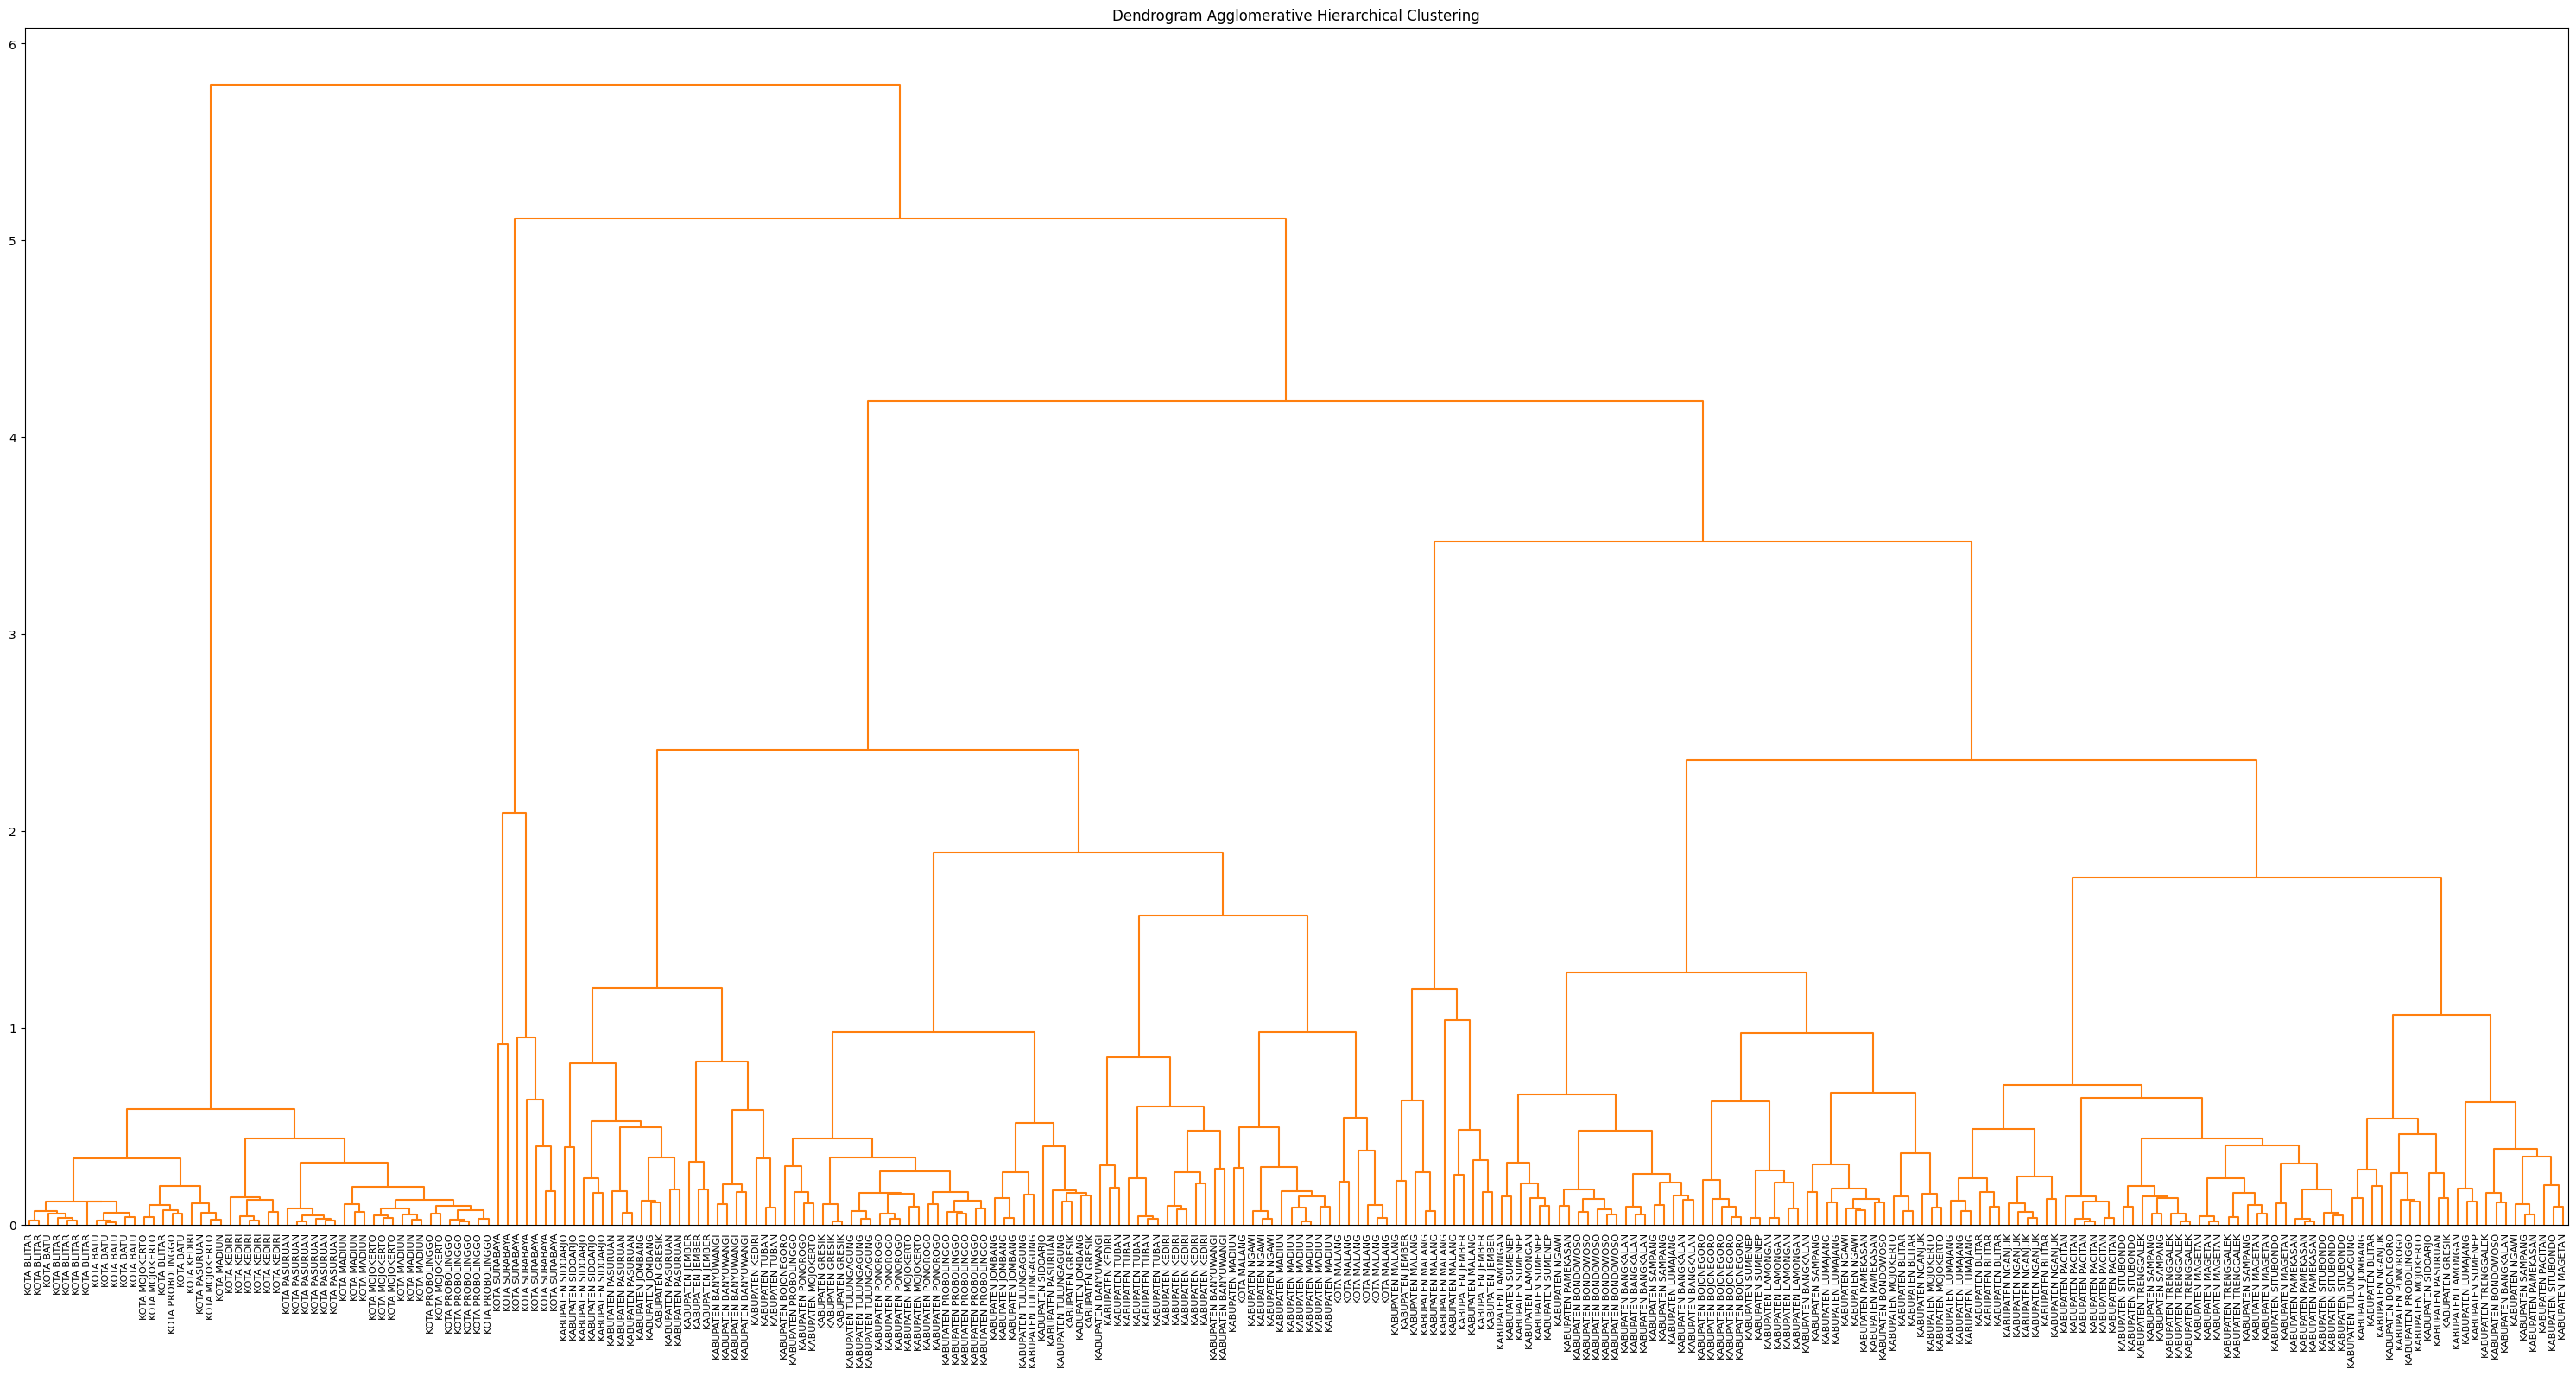

In [7]:
#===============================================================================
# 2.1. DENDROGRAM
#===============================================================================

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels=df_minmax_ahc["nama_kabupaten_kota"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

#plt.axhline(y=8, color="r", linestyle="--", linewidth=1)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()

In [8]:
#===============================================================================
# 3. EVALUASI CLUSTER
#===============================================================================

hasil_evaluasi = []

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    cluster = model.fit_predict(df_minmax_ahc[kolom_numerik])
    
    silhouette = silhouette_score(df_minmax_ahc[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_minmax_ahc[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_minmax_ahc[kolom_numerik], cluster)
    
    hasil_evaluasi.append({
    'Jumlah Cluster (K)': k,
    'Silhouette Score': silhouette,
    'Davies-Bouldin Index': dbi,
    'Calinski-Harabasz Index': chi
    })
    
hasil_evaluasi = pd.DataFrame(hasil_evaluasi)
    
print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.2784,0.7949,82.3182
1,3,0.3189,0.7491,96.2787
2,4,0.3034,1.1541,105.3374
3,5,0.3335,1.0270,112.0979
4,6,0.3263,1.1041,107.1539
5,7,0.2973,1.1544,107.1020
6,8,0.3028,1.0660,106.9570
7,9,0.3101,1.0868,106.9762
8,10,0.3066,1.0898,107.6710


In [9]:
# --------------------------
# 3.1. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 5


In [10]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 3


In [11]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 5


_Pemotongan klaster yang diggunakan_

In [12]:
k = 5

In [13]:
#===============================================================================
# 4. CLUSTERING DENGAN K OPTIMAL
#===============================================================================

ahc = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward",
    metric="euclidean"
)

ahc.fit(df_minmax_ahc[kolom_numerik])

AgglomerativeClustering(n_clusters=5)

In [14]:
#===============================================================================
# 5. SIMPAN LABEL CLUSTER
#===============================================================================

print("========== LABEL CLUSTER ==========")
df_hasil = df_minmax_ahc.copy()
df_hasil["cluster_ahc"] = ahc.labels_ + 1
df_hasil

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_ahc
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,0.219512,0.348837,0.167795,0.026609,0.037795,0.047024,0.003308,0.157688,2
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.292683,0.441860,0.250967,0.024344,0.070104,0.053427,0.005678,0.285919,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,0.073171,0.441860,0.185687,0.042838,0.052861,0.046214,0.003219,0.211696,2
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.341463,0.418605,0.294487,0.049632,0.079509,0.131278,0.006033,0.337123,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,0.146341,0.418605,0.261122,0.043971,0.056780,0.074507,0.004575,0.379016,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,0.195122,0.000000,0.000484,0.000000,0.006618,0.021517,0.003244,0.025885,4
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,0.146341,0.000000,0.001934,0.000000,0.018375,0.018280,0.001242,0.001156,4
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,0.146341,0.000000,0.002418,0.000000,0.029261,0.027137,0.009188,0.021809,4
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,0.975610,0.534884,0.033366,0.000000,0.632326,0.972493,0.028744,1.000000,3


In [15]:
#================================================================================
# 5.1. JUMLAH ANGGOTA CLUSTER
#================================================================================

jumlah_cluster = (
    df_hasil["cluster_ahc"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_ahc
1     87
2    112
3      7
4     49
5     11
Name: count, dtype: int64

In [16]:
#===============================================================================
# 5.2. PROFIL CLUSTER
#===============================================================================
profil_cluster = (
    df_hasil
    .groupby("cluster_ahc")[kolom_numerik]
    .mean()
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster_ahc,,,,,,,,
1,0.435660,0.325047,0.397541,0.051281,0.126803,0.167576,0.045295,0.413820
2,0.099739,0.486503,0.284380,0.020745,0.070861,0.168019,0.024463,0.300922
3,0.996516,0.514950,0.702888,0.330251,0.756783,0.689772,0.286082,0.984957
4,0.102539,0.044613,0.101932,0.020562,0.046479,0.034213,0.014846,0.024596
5,0.062084,0.940803,0.499692,0.055036,0.201848,0.283818,0.076125,0.860334


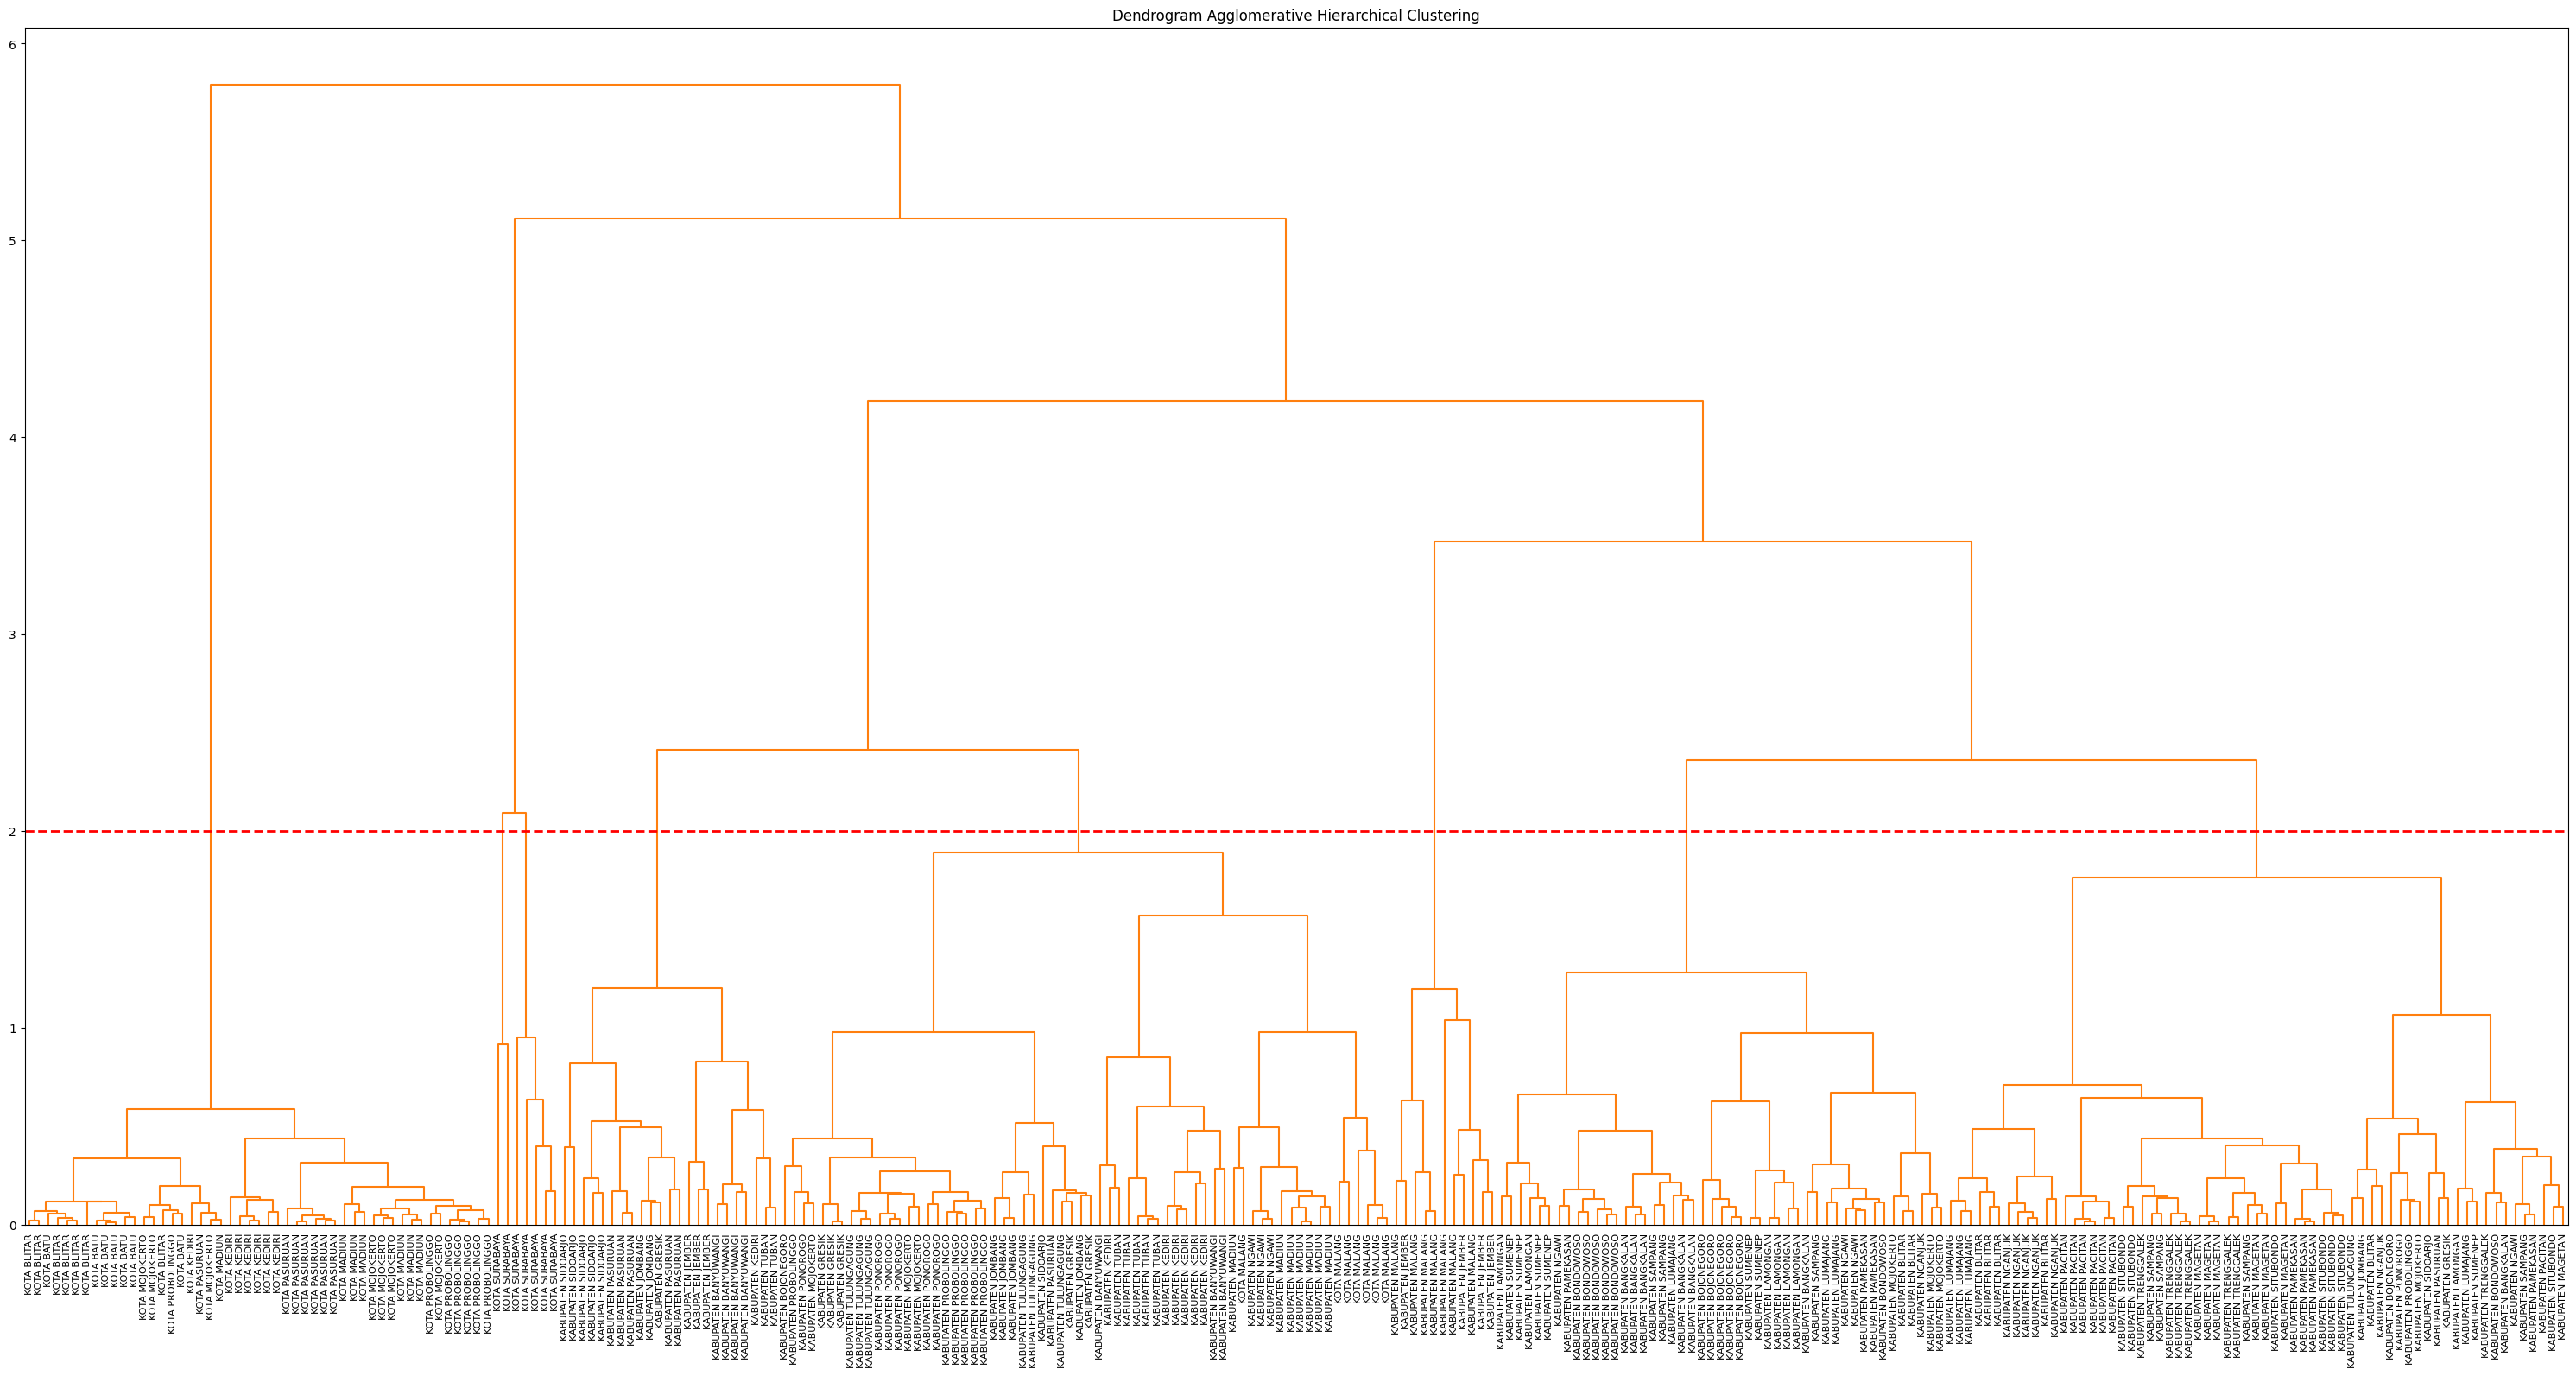

In [17]:

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels=df_minmax_ahc["nama_kabupaten_kota"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

plt.axhline(y=2, color="r", linestyle="--", linewidth=2)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()